In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math #这里的math用于math.ceil()对数据向上取整
import copy

训练数据

In [2]:
x_train=np.array([650, 850, 1100, 1450, 1800, 2200])
y_train=np.array([150, 200, 280, 350, 430, 520])
length = x_train.shape[0]
y_final=np.zeros(length)

In [3]:
def update_hat (x,y,w,b):
    for i in range(length):
        y_final[i]=w*x[i]+b

编写梯度计算函数

In [4]:
def compute_gradient(x,y,w,b):
    midsum_w=0
    midsum_b=0
    for i in range(length):
        f_x=w*x[i]+b-y[i]
        mid_w=f_x*x[i]
        mid_b=f_x
        midsum_w+=mid_w
        midsum_b+=mid_b
    fin_sum_w=(1/length)*midsum_w
    fin_sum_b=(1/length)*midsum_b
    return fin_sum_w,fin_sum_b

模拟梯度下降

In [5]:
def gradient_decent (x,y,w,b,num,alpha,gradient_function):
    w_in=copy.deepcopy(w)
    b_in=copy.deepcopy(b)
    for i in range(num):
        gra_w,gra_b=gradient_function(x,y,w_in,b_in)
        w_in=w_in-alpha*gra_w
        b_in=b_in-alpha*gra_b
    print(w_in,b_in)
    return w_in,b_in

In [6]:
w_unit=0
b_unit=0
#学习率在这里不宜过大因为导致w和b变化太大直接失衡，越跑越远
temp_alpha=1.2e-7
num_unit=50000
w,b=gradient_decent(x_train,y_train,w_unit,b_unit,num_unit,temp_alpha,compute_gradient)
update_hat(x_train,y_train,w,b)

0.23935980273604524 0.0032888458383773063


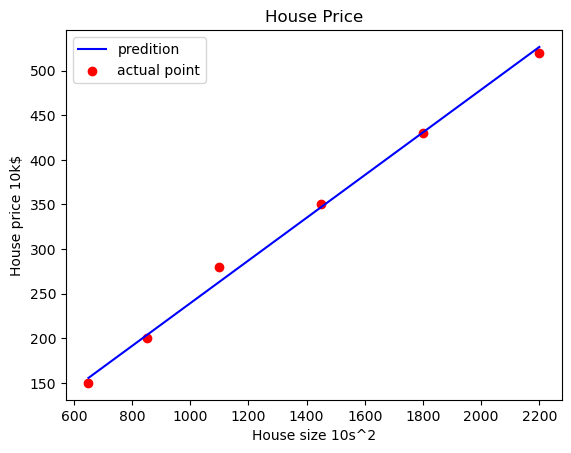

In [7]:
plt.plot(x_train,y_final,c='b',label="predition")
plt.scatter(x_train,y_train,c='r',label="actual point")
plt.title("House Price")
plt.ylabel("House price 10k$")
plt.xlabel("House size 10s^2")
plt.legend()
plt.show()